# Lab6 - Monte Carlo Dropout

Credits:

- the notebook is originally created by Daniel Kałuża
- modified and extended by Sebastian Stawicki and Piotr Biczyk

In [Gal & Ghahramani (2016)]( https://arxiv.org/abs/1506.02142), it was shown that dropout in neural networks can be employed to approximate a Bayesian model, and further, it can be used to assess the model's uncertainty.

We are going to implement Monte-Carlo dropout in a neural network and use it as a model-specific informativeness measure in an active learning loop.

## 0. Import libraries


In [16]:
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
from torchvision import datasets


## 1. Data preparation

We are going to use Fashion MNIST dataset. It was already used in one of the previous labs. This time, however, we will use torchvision environment to load and prepare the data. The dataset consists of 60k training images and 10k test images of clothing items such as T-shirts, trousers, pullovers, etc. Each image is 28x28 pixels in grayscale. The dataset is divided into 10 classes, each representing a different clothing item. The goal is to classify the images into the correct class.

Use `FashionMNIST` from `torchvision.datasets` to load the train and test datasets. Utilize `torchvision.transforms` to transform the original PIL images to normalized tensors.

E.g.:

```python
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.Compose([
        # TODO: add transformations
    ])
)
```

Hint: transforms.ToTensor() converts PIL images to float tensors and rescales pixel values from 0–255 to 0.0–1.0. That's the minimum you need. Optionally, transforms.Normalize((mean,), (std,)) can center your data — note the single-element tuples, since FashionMNIST is grayscale (1 channel). Don't divide by 255 manually if you're already using ToTensor().


In [17]:
# write your code here
 
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.Compose([
        transforms.ToTensor()
    ])
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)


### Get familiar with the dataset

Investigate the distribution of the target classes in the dataset.

<class 'torch.Tensor'>
torch.Size([60000, 28, 28])
[0 1 2 3 4 5 6 7 8 9]
[6000 6000 6000 6000 6000 6000 6000 6000 6000 6000]


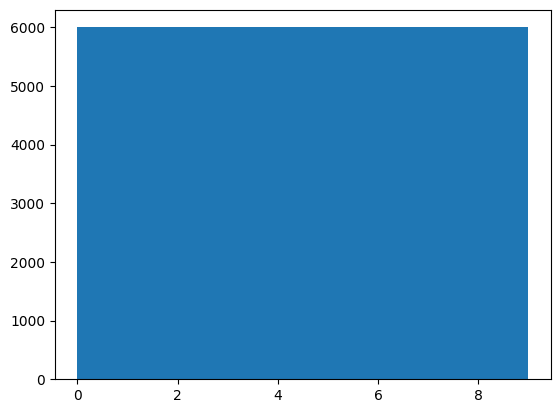

In [18]:
# write your code here

print(type(training_data.data))
print(training_data.data.shape)

first_el, first_class = training_data[0]
#print(first_el)
#print(first_class)

unique, uniqe_counts = np.unique(training_data.targets, return_counts=True)
print(unique)
print(uniqe_counts)

plt.hist(training_data.targets, bins=10)
plt.show()


### Prepare a function to display images

Implement a function that can display a single image from the dataset. Let the function take also an optional argument that, if provided, will display the actual class name as the title of image.

Use the function to visualize a few images.

E.g.:

```python
def plot_image(img, labels_map, y=None):
    #TODO

for i in range(5):
    sample, label = training_data[i]
    plot_image(sample.squeeze(), training_data.classes, label)
```

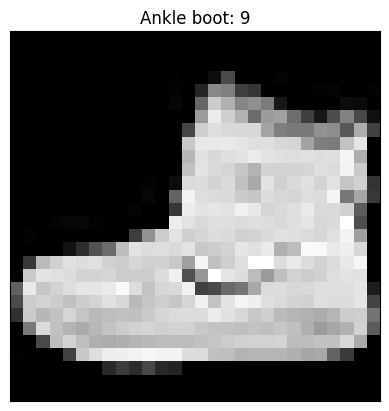

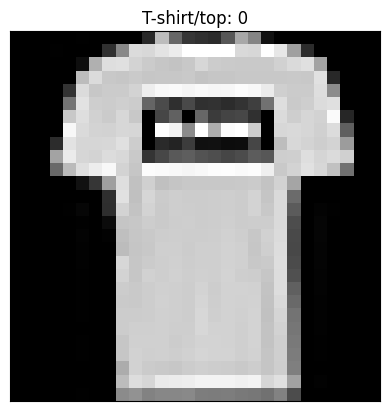

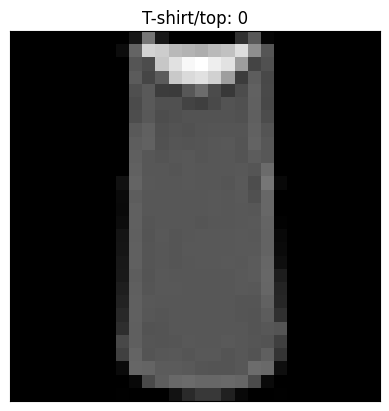

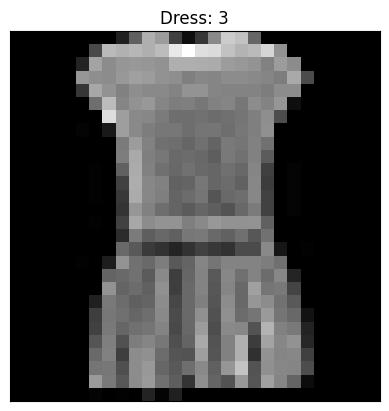

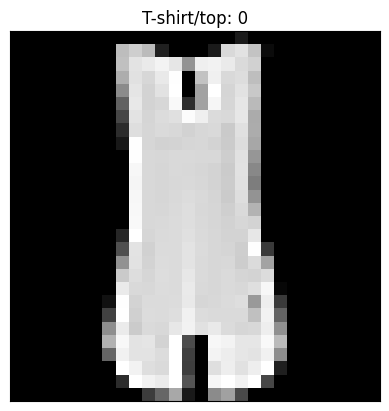

In [19]:
# write your code here

def plot_image(img, labels_map, y=None):
    plt.imshow(img, cmap="gray")
    if y is not None:
        plt.title(f"{labels_map[y]}: {y}")
    plt.xticks([])
    plt.yticks([])
    plt.show()
    return

for i in range(5):
    sample, label = training_data[i]
    plot_image(sample.squeeze(), training_data.classes, label)


### Prepare data loaders for training and testing datasets

Use `torch.utils.data.DataLoader` to create data loaders for the training and testing datasets. Use data loaders with batch size equal to 64 and enable shuffling for the training dataset.

Hint: You can define BATCH_SIZE = 64 as a named constant here — it will be referenced later by the training function.

In [20]:
# write your code here
BATCH_SIZE = 64

loader_train = DataLoader(training_data, batch_size=BATCH_SIZE, shuffle=True)
loader_test = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

## 2. Define the model

We are going to use a convolution neural network with several convolutional layers with ReLU activations, followed by max pooling and dropout layers. The final layer will be a fully connected layer, preceded also by a dropout layer. 
We are going to use Adam optimizer and CrossEntropyLoss as the loss function.

Note on architecture dimensions: Trace the tensor shape through the network to understand why nn.Linear(32, 10) is correct. The input is 1×28×28. Each Conv2d(kernel=3) without padding reduces spatial dimensions by 2, each MaxPool2d(2) halves them. The final spatial size before Flatten() is 1×1 with 32 channels, hence 32 inputs to the linear layer. If you experiment with different kernel sizes or add padding, this number must change.

Note on dropout rate: nn.Dropout() defaults to p=0.5. Three dropout layers at 50% is aggressive — it slows convergence but produces high variance between MC Dropout passes, which is useful for this lab. In production CNNs you'd typically use lower rates (0.1–0.3) for convolutional layers.

In [21]:
model = nn.Sequential(
          nn.Conv2d(1, 32, 3),
          nn.ReLU(),
          nn.MaxPool2d(2),
          nn.Dropout(),
          nn.Conv2d(32, 64, 3),
          nn.ReLU(),
          nn.MaxPool2d(2),
          nn.Dropout(),
          nn.Conv2d(64, 32, 3),
          nn.ReLU(),
          nn.MaxPool2d(2),
          nn.Flatten(),
          nn.Dropout(),
          nn.Linear(32, 10)
        )
model = model.float()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

### Let us define functions for training and evaluation

Let the functions be defined as follows.

Note: The torch.device(...) call below creates a device object but doesn't assign it or move anything. For this lab we work on CPU, which is fine. In your own projects, remember to store the device and call model.to(device) and move batches with X.to(device).

In [22]:
from sklearn.metrics import balanced_accuracy_score

# modified version of: https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html#full-implementation
# license of this fragment: https://github.com/pytorch/pytorch/blob/master/LICENSE

torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_loop(dataloader, model, loss_fn, optimizer, num_epochs=1, print_stats=True):
    size = len(dataloader.dataset)
    for epoch in range(num_epochs):
        # Set the model to training mode - important for batch normalization and dropout layers
        model.train()
        for batch, (X, y) in enumerate(dataloader):
            # Compute prediction and loss
            pred = model(X)
            loss = loss_fn(pred, y)
            
            # Backpropagation
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            if print_stats:
                if batch % 100 == 0:
                    loss, current = loss.item(), batch * BATCH_SIZE + len(X)
                    print(f"Epoch {epoch}, loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")



def test_loop(dataloader, model, loss_fn, print_stats=True):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, labels_estimated, correct_labels = 0, [], []

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct_labels.extend(y.numpy())
            labels_estimated.extend((pred.argmax(1)).numpy())

    test_loss /= num_batches
    bac = balanced_accuracy_score(correct_labels, labels_estimated)
    if print_stats:
        print(f"Test Error: \n BAC: {bac:>0.3f}, Avg loss {test_loss:>8f}\n")
    
    return bac, test_loss


### Experiment with the model

Train the model for several epochs and evaluate it on the test dataset.

Hint: 5–10 epochs is a reasonable starting range. Watch the loss - once it plateaus, additional epochs add little. Keep in mind that in the active learning loop (Section 5), you'll retrain the model multiple times on small datasets, so you'll want to keep epoch counts modest there too (3–5).

In [23]:
# write your code here

train_loop(dataloader=loader_train, model=model, loss_fn=loss_fn, optimizer=optimizer, num_epochs=10, print_stats=True)

test_loop(dataloader=loader_test, model=model, loss_fn=loss_fn, print_stats=True)



Epoch 0, loss: 2.273398  [   64/60000]
Epoch 0, loss: 1.421182  [ 6464/60000]
Epoch 0, loss: 1.209548  [12864/60000]
Epoch 0, loss: 1.190471  [19264/60000]
Epoch 0, loss: 0.763494  [25664/60000]
Epoch 0, loss: 0.895543  [32064/60000]
Epoch 0, loss: 0.912906  [38464/60000]
Epoch 0, loss: 0.781602  [44864/60000]
Epoch 0, loss: 0.904806  [51264/60000]
Epoch 0, loss: 0.952878  [57664/60000]
Epoch 1, loss: 0.872194  [   64/60000]
Epoch 1, loss: 0.634844  [ 6464/60000]
Epoch 1, loss: 0.698355  [12864/60000]
Epoch 1, loss: 0.980854  [19264/60000]
Epoch 1, loss: 0.720298  [25664/60000]
Epoch 1, loss: 0.995284  [32064/60000]
Epoch 1, loss: 0.840434  [38464/60000]
Epoch 1, loss: 0.818417  [44864/60000]
Epoch 1, loss: 0.739909  [51264/60000]
Epoch 1, loss: 0.760551  [57664/60000]
Epoch 2, loss: 0.862310  [   64/60000]
Epoch 2, loss: 0.722126  [ 6464/60000]
Epoch 2, loss: 0.757778  [12864/60000]
Epoch 2, loss: 0.764487  [19264/60000]
Epoch 2, loss: 0.756512  [25664/60000]
Epoch 2, loss: 0.750851  

(0.8263999999999999, 0.4932922098287352)

## 3. Create a function to compute entropy-based uncertainty

Create a function that computes the entropy of our neural network model's predictions for a given dataset subset. Add an argument that will allow you to specify whether to compute predictions with or without dropout applied. For the dropout-enabled case, we would like to perform several forward passes (`n_passes = 20` by default) and compute the average of the entropy values. 

Hint: consider using either `model.train()` or `model.eval()` to enable or disable dropout. This is the practical way. Alternatively, if you want to avoid approximation, you can run N passes with dropout ON, collect all softmax outputs, then compute: term 1 = entropy of the mean softmax, term 2 = mean of individual entropies. This is more correct and also more efficient (one set of forward passes instead of two).

Warning: Make sure that you are computing entropy on proper probability distributions. You may need to apply a softmax function to the model's output before computing the entropy.

E.g.:

```python
def uncertainty(model, data, use_dropout, n_passes=20): 
    # TODO: implement the function
```

Reminder — softmax: The model outputs raw logits (no activation after nn.Linear). This is correct for CrossEntropyLoss, which handles softmax internally. However, entropy requires a valid probability distribution — you must apply torch.softmax() explicitly in this function. Do not add softmax to the model itself, as that would break the loss.


Reminder — numerical stability: log(0) produces -inf. Clamp probabilities before taking the log: torch.clamp(probs, min=1e-8), or use torch.distributions.Categorical(probs).entropy().


Reminder — gradients: Wrap your forward passes in torch.no_grad(). You're not backpropagating here, and with 20 passes over many samples, forgetting this will noticeably slow execution.

In [39]:
# write your code here

def uncertainty(model, data, use_dropout=True, n_passes=20):
    # zapamiętaj tryb modelu
    prev_mode = model.training

    if use_dropout:
        model.train()
        probs_all = []
        with torch.no_grad():
            for i in range(n_passes):
                logits = model(data)
                probs = torch.softmax(logits, dim=1)
                probs_all.append(probs)

            probs_all = torch.stack(probs_all, dim=0)      # [T, batch, classes]
            probs_mean = probs_all.mean(dim=0)             # [batch, classes]

            # Term 1: entropy of mean distribution
            pm = torch.clamp(probs_mean, min=1e-8)
            term1 = -(pm * pm.log()).sum(dim=1)            # [batch]

            # Term 2: mean of entropies
            pa = torch.clamp(probs_all, min=1e-8)
            entropies_each = -(pa * pa.log()).sum(dim=2)   # [T, batch]
            term2 = entropies_each.mean(dim=0)             # [batch]
        
        model.train(prev_mode)
        return term1, term2


    else:
        model.eval()
        with torch.no_grad():
            logits = model(data)
            probs = torch.softmax(logits, dim=1)
            probs_clamped = torch.clamp(probs, min=1e-8)
            entropy = -torch.sum(probs_clamped * torch.log(probs_clamped), dim=1)

        model.train(prev_mode)
        return entropy


## 4. Implement BALD informativeness function

Some useful links and references:
- https://arxiv.org/abs/1112.5745
- https://ozanciga.wordpress.com/2023/10/29/bald-bayesian-active-learning-by-disagreements-simplified/
  

We want to implement BALD (Bayesian Active Learning by Disagreement) informativeness function. The idea is to select the most informative samples based on the model's uncertainty:

$$
u^*_{BALD} = \arg\max_{u} H(y|u, U_{tr}) - E_{\theta\sim p(\theta|U_{tr})}[H(y|u,\theta) ]
$$

where $H$ is entropy function, $U_{tr}$ is current training set and  $θ$ are the parameters of the model. 

To obtain the first and the second part of the difference, you can use the function implemented in the previous step, with dropout disabled and enabled, respectively.


Implementation hint: BALD requires two quantities computed from stochastic forward passes (dropout ON):

Term 1 — Total predictive uncertainty: average the softmax outputs across all N passes to get a mean predictive distribution, then compute the entropy of that mean distribution.
Term 2 — Expected individual uncertainty: compute the entropy of each individual pass's softmax output, then average those entropies.

BALD = Term 1 − Term 2.
Note that Term 1 ≥ Term 2 always (by Jensen's inequality), so BALD is non-negative.
Simplified alternative: The notebook's uncertainty function with use_dropout=False can approximate Term 1 with a single deterministic pass, while use_dropout=True directly gives Term 2. This is acceptable but is an approximation — the proper version computes both terms from the same set of stochastic passes.


Intuition check: High BALD means the dropout passes disagree with each other (the model is epistemically uncertain). Low BALD means either the model is confident or all passes are confused in the same way (aleatoric uncertainty). BALD specifically targets samples where more labeled data would help.
In other words - if every single dropout pass is individually uncertain (high entropy per pass) and they all agree with each other, then the average also has high entropy — but the two terms cancel out, BALD is low. That's aleatoric uncertainty. The data is just noisy. But if individual passes are each fairly confident in different answers, the average is smeared out (high first term) while individual entropies are low (low second term) — BALD is high. The model's "committee of sub-networks" is disagreeing, which means more data from that region would actually help.



In [45]:
# write your code here

def bald_score(model, data, n_passes=20):
    term1, term2 = uncertainty(model, data, use_dropout=True, n_passes=n_passes)
    return term1 - term2

def BALD_selector(model, data, top_k=None, n_passes=20):
    scores = bald_score(model, data, n_passes=n_passes)   # [N]
    # upewniamy się, że indeksy są na CPU
    idx = torch.argsort(scores, descending=True).cpu()
    # wybieramy próbki
    selected = data[idx]
    if top_k is not None:
        idx = idx[:top_k]
        selected = selected[:top_k]
    return idx, selected

"""
def BALD_subset_selector(model, dataset, subset_idx=None, top_k=None, n_passes=20):
    # Jeśli nie podano subset_idx, używamy całego datasetu
    if subset_idx is None:
        subset_idx = torch.arange(len(dataset))
    # Tworzymy Subset
    subset = torch.utils.data.Subset(dataset, subset_idx)
    # Konwersja subsetu do tensora (zakładam, że dataset zwraca (x, y))
    xs = torch.stack([subset[i][0] for i in range(len(subset))])
    scores = bald_score(model, xs, n_passes=n_passes)  # tensor [N]
    # Sortowanie malejąco
    sorted_local_idx = torch.argsort(scores, descending=True)
    # Wybór top_k
    if top_k is not None:
        sorted_local_idx = sorted_local_idx[:top_k]
    # Mapowanie lokalnych indeksów subsetu na globalne indeksy datasetu
    selected_global_idx = subset_idx[sorted_local_idx]

    return selected_global_idx, scores[sorted_local_idx]
"""

# Funkcja pomocnicza: liczenie BALD w batchach
def compute_bald_batched(model, subset, batch_size, n_passes):
    scores_list = []

    for start in range(0, len(subset), batch_size):
        end = start + batch_size
        batch = [subset[i][0] for i in range(start, min(end, len(subset)))]
        xs = torch.stack(batch)  # CPU-only

        # policz BALD dla batcha
        batch_scores = bald_score(model, xs, n_passes=n_passes)
        scores_list.append(batch_scores)

    return torch.cat(scores_list)

def BALD_subset_selector(model, dataset, subset_idx=None, top_k=None,
                         n_passes=40, batch_size=64):
    # Jeśli nie podano subset_idx, używamy całego datasetu
    if subset_idx is None:
        subset_idx = torch.arange(len(dataset))

    # Tworzymy Subset
    subset = torch.utils.data.Subset(dataset, subset_idx)

    # Liczymy BALD dla całego subsetu, ale w batchach
    scores = compute_bald_batched(model, subset, batch_size, n_passes)
    # Sortowanie malejąco
    sorted_local_idx = torch.argsort(scores, descending=True)
    # Wybór top_k
    if top_k is not None:
        sorted_local_idx = sorted_local_idx[:top_k]
    # Mapowanie lokalnych indeksów subsetu na globalne indeksy datasetu
    selected_global_idx = subset_idx[sorted_local_idx]
    return selected_global_idx, scores[sorted_local_idx]



def random_selector(model, dataset, subset_idx, top_k, **kwargs):
    perm = torch.randperm(len(subset_idx))
    selected_idx = subset_idx[perm[:top_k]]
    return selected_idx, None

## 5. Prepare an active learning experiment

Use your own active learning framework to perform an experiment with the implemented BALD informativeness measure. 

Randomly sample 1% of the training dataset to form the initial batch, the remaining 99% will be used as the pool. The active learning loop should run for K(=5 by default) iterations. In each iteration, choose L (=64 by default) samples from the pool to be added to active learn training set. The samples should be chosen based on the maximum informativeness score. The created models should be evaluated (with BAC measure) on the test dataset after each iteration.

Compare the results with the baseline approach, where random batch sampling is used.

Implementation roadmap:

Initial split: Use torch.randperm(len(training_data)) to generate a random permutation of indices. Take the first 1% as your initial labeled set, the rest as the pool. Use torch.utils.data.Subset(training_data, indices) to create dataset views.

AL loop (K iterations):
Create a DataLoader from the current labeled Subset and train a freshly initialized model (reinitialize weights each iteration for a clean comparison).
Evaluate on the test set using test_loop and record BAC.
Compute BALD scores for pool samples. Scalability tip: computing BALD on the entire pool (~59k samples) with 20 passes is slow. Consider subsampling the pool — randomly draw ~2000 candidates, score those, pick the top L.
Select the top-L indices by BALD score, move them from pool to labeled set.

Random baseline: 
Run the same loop but replace BALD selection with random sampling from the pool. Use the same initial labeled set and the same hyperparameters — only the selection strategy should differ.

Comparison: 
Plot BAC vs. iteration for both strategies on the same axes.

Design decision: 
Reinitializing the model each iteration is cleaner experimentally. Fine-tuning from the previous checkpoint is faster but introduces path dependence. Choose deliberately and note your choice.

In [55]:
def create_model():
    model = nn.Sequential(
        nn.Conv2d(1, 32, 3),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Dropout(),
        nn.Conv2d(32, 64, 3),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Dropout(),
        nn.Conv2d(64, 32, 3),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Flatten(),
        nn.Dropout(),
        nn.Linear(32, 10)
    )
    return model.float()


def al_iteration(model_class, train_dataset, test_loader,
                 labeled_idx,
                 pool_idx,
                 L, selector_fn,
                 n_passes=50,
                 num_epochs=5,
                 candidate_size=2000):

    labeled_set = torch.utils.data.Subset(train_dataset, labeled_idx)
    labeled_loader = DataLoader(labeled_set, batch_size=64, shuffle=True)

    model = model_class()  # CPU-only
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()

    train_loop(labeled_loader, model, loss_fn, optimizer, num_epochs=num_epochs)

    bac, _ = test_loop(test_loader, model, loss_fn)

    if len(pool_idx) > candidate_size:
        candidate_idx = pool_idx[torch.randperm(len(pool_idx))[:candidate_size]]
    else:
        candidate_idx = pool_idx

    selected_idx, _ = selector_fn(
        model,
        train_dataset,
        subset_idx=candidate_idx,
        top_k=L,
        n_passes=n_passes
    )

    new_labeled_idx = torch.cat([labeled_idx, selected_idx])

    mask = torch.ones(len(pool_idx), dtype=bool)
    remove_mask = torch.isin(pool_idx, selected_idx)
    mask[remove_mask] = False
    new_pool_idx = pool_idx[mask]

    return new_labeled_idx, new_pool_idx, bac



def active_learning_experiment(model_class, train_dataset, test_loader,
                               K=5, L=64, initial_ratio=0.01,
                               num_epochs=5,
                               selector_fn=None):

    N = len(train_dataset)
    perm = torch.randperm(N)

    initial_size = max(1, int(initial_ratio * N))
    labeled_idx = perm[:initial_size]
    pool_idx = perm[initial_size:]

    bac_history = []

    for it in range(K):
        print(f"\n=== Active Learning iteration {it+1}/{K} ===")

        labeled_idx, pool_idx, bac = al_iteration(
            model_class, train_dataset, test_loader,
            labeled_idx, pool_idx,
            L=L,
            num_epochs=num_epochs,
            selector_fn=selector_fn
        )

        bac_history.append(bac)

    return bac_history



In [ ]:
# write your code here
num_epochs=5
K=50

bac_bald = active_learning_experiment(
    create_model,
    training_data,
    loader_test,
    K=K,
    L=64,
    num_epochs=num_epochs,
    initial_ratio=0.01,
    selector_fn=BALD_subset_selector
)



=== Active Learning iteration 1/50 ===
Epoch 0, loss: 2.299057  [   64/  600]
Epoch 1, loss: 2.232953  [   64/  600]
Epoch 2, loss: 2.261581  [   64/  600]
Epoch 3, loss: 2.125433  [   64/  600]
Epoch 4, loss: 2.025312  [   64/  600]
Test Error: 
 BAC: 0.331, Avg loss 1.895753


=== Active Learning iteration 2/50 ===
Epoch 0, loss: 2.295380  [   64/  664]
Epoch 1, loss: 2.322786  [   64/  664]
Epoch 2, loss: 2.064169  [   64/  664]
Epoch 3, loss: 1.960033  [   64/  664]
Epoch 4, loss: 1.900589  [   64/  664]
Test Error: 
 BAC: 0.412, Avg loss 1.746848



In [ ]:


bac_random = active_learning_experiment(
    create_model,
    training_data,
    loader_test,
    K=K,
    L=64,
    num_epochs=num_epochs,
    initial_ratio=0.01,
    selector_fn=random_selector
)


=== Active Learning iteration 1/50 ===
Epoch 0, loss: 2.316911  [   64/  600]
Epoch 1, loss: 2.247241  [   64/  600]
Epoch 2, loss: 2.138611  [   64/  600]
Epoch 3, loss: 1.926249  [   64/  600]
Epoch 4, loss: 1.581795  [   64/  600]
Epoch 5, loss: 1.684621  [   64/  600]
Epoch 6, loss: 1.464734  [   64/  600]
Test Error: 
 BAC: 0.621, Avg loss 1.217978


=== Active Learning iteration 2/50 ===
Epoch 0, loss: 2.310180  [   64/  664]
Epoch 1, loss: 2.219674  [   64/  664]
Epoch 2, loss: 2.122339  [   64/  664]
Epoch 3, loss: 2.033194  [   64/  664]
Epoch 4, loss: 1.688554  [   64/  664]
Epoch 5, loss: 1.424343  [   64/  664]
Epoch 6, loss: 1.468436  [   64/  664]
Test Error: 
 BAC: 0.594, Avg loss 1.219611


=== Active Learning iteration 3/50 ===
Epoch 0, loss: 2.278635  [   64/  728]
Epoch 1, loss: 2.273744  [   64/  728]
Epoch 2, loss: 2.116175  [   64/  728]
Epoch 3, loss: 1.870358  [   64/  728]
Epoch 4, loss: 1.954482  [   64/  728]
Epoch 5, loss: 1.648862  [   64/  728]
Epoch 6, l

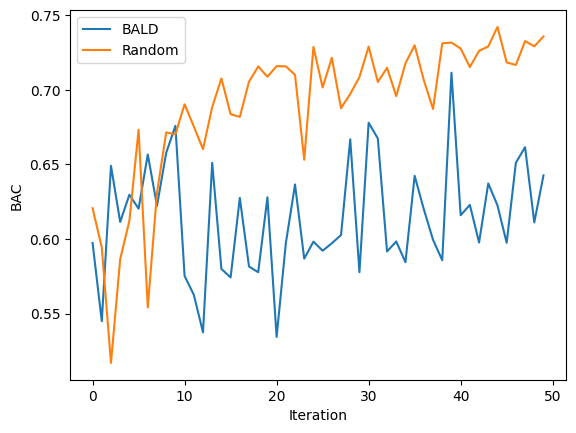

In [ ]:
plt.plot(bac_bald, label="BALD")
plt.plot(bac_random, label="Random")
plt.xlabel("Iteration")
plt.ylabel("BAC")
plt.legend()
plt.show()
